# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [1]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [2]:
df = pd.read_csv('CleanedAviationData.csv')
df

,Event.Date,Location,Country,Injury.Severity,Aircraft.damage,Make,Model,Number.of.Engines,Engine.Type,Purpose.of.flight,...,Weather.Condition,Broad.phase.of.flight,Total.Occupants,Fatal.Serious.Injuries,Fatal.Serious.Rate,Destroyed,Damage.Severity,Make_Model,State,State.Name
0,1983-01-01,"NEWPORT, OR",United States,Non-Fatal,Substantial,CESSNA,182P,1.0,Reciprocating,Personal,...,VMC,Approach,4.0,0.0,0.0,0.0,Substantial,CESSNA 182P,OR,Oregon
1,1983-01-01,"WOODBINE, IA",United States,Non-Fatal,Substantial,CESSNA,182RG,1.0,Reciprocating,Personal,...,VMC,Landing,2.0,0.0,0.0,0.0,Substantial,CESSNA 182RG,IA,Iowa
2,1983-01-01,"MARYVILLE, MO",United States,Non-Fatal,Substantial,CESSNA,182P,1.0,Reciprocating,Personal,...,VMC,Takeoff,1.0,0.0,0.0,0.0,Substantial,CESSNA 182P,MO,Missouri
3,1983-01-01,"UPLAND, CA",United States,Non-Fatal,Substantial,PIPER,PA-28R-200,1.0,Reciprocating,Personal,...,VMC,Approach,2.0,0.0,0.0,0.0,Substantial,PIPER PA-28R-200,CA,California
4,1983-01-01,"SPRINGBROOK, WI",United States,Non-Fatal,Substantial,CESSNA,140,1.0,Reciprocating,Instructional,...,VMC,Landing,2.0,0.0,0.0,0.0,Substantial,CESSNA 140,WI,Wisconsin
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56297,2022-12-26,"Annapolis, MD",United States,Minor,NaN,PIPER,PA-28-151,NaN,NaN,Personal,...,NaN,NaN,1.0,1.0,1.0,NaN,NaN,PIPER PA-28-151,MD,Maryland
56298,2022-12-26,"Hampton, NH",United States,NaN,NaN,BELLANCA,7ECA,NaN,NaN,NaN,...,NaN,NaN,0.0,0.0,NaN,NaN,NaN,BELLANCA 7ECA,NH,New Hampshire
56299,2022-12-26,"Payson, AZ",United States,Non-Fatal,Substantial,AMERICAN CHAMPION,8GCBC,1.0,NaN,Personal,...,VMC,NaN,1.0,0.0,0.0,0.0,Substantial,AMERICAN CHAMPION 8GCBC,AZ,Arizona
56300,2022-12-26,"Morgan, UT",United States,NaN,NaN,CESSNA,210N,NaN,NaN,Personal,...,NaN,NaN,0.0,0.0,NaN,NaN,NaN,CESSNA 210N,UT,Utah


## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [3]:
PASSENGER_THRESHOLD = 20

# Total.Occupants is often below actual seating capacity, so taking the 75th percentile
# captures high typical occupancy which should be better for estimating size than max()
type_capacity = df.groupby('Make_Model')['Total.Occupants'].quantile(0.75)

df['Aircraft.Capacity'] = df['Make_Model'].map(type_capacity)
df['Size.Class'] = np.where(
    df['Aircraft.Capacity'] >= PASSENGER_THRESHOLD, 'Large', 'Small'
)

small_planes_df = df[df['Size.Class'] == 'Small'].copy()
large_planes_df = df[df['Size.Class'] == 'Large'].copy()

summary = (
    df.groupby('Size.Class')
      .agg(accidents=('Make_Model', 'size'),
           plane_types=('Make_Model', 'nunique'),
           makes=('Make', 'nunique'),
           median_occupants=('Total.Occupants', 'median'),
           mean_fatal_serious_rate=('Fatal.Serious.Rate', 'mean'),
           mean_destroyed_rate=('Destroyed', 'mean'))
      .loc[['Small', 'Large']]
)
print(f"Split at {PASSENGER_THRESHOLD} occupants: "
      f"{len(small_planes_df):,} small-aircraft accidents / "
      f"{len(large_planes_df):,} large\n")
display(summary.round(3))

straddle = set(small_planes_df['Make_Model']) & set(large_planes_df['Make_Model'])
print(f"Plane types appearing in both groups (should be 0): {len(straddle)}")

Split at 20 occupants: 55,118 small-aircraft accidents / 1,184 large



,accidents,plane_types,makes,median_occupants,mean_fatal_serious_rate,mean_destroyed_rate
Size.Class,,,,,,
Small,55118,2162,47,2.0,0.278,0.210
Large,1184,269,9,108.0,0.112,0.177


Plane types appearing in both groups (should be 0): 0


#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

Small (< 20 occupants): 47 makes, 46 with >= 10 accidents, showing the 15 lowest


,mean_rate,accidents
Make,,
WACO,12.9%,111
GREAT LAKES,13.9%,54
MAULE,16.3%,496
MCDONNELL DOUGLAS,17.3%,27
HELIO,17.5%,71
CUB CRAFTERS,17.8%,76
BOEING,17.8%,372
AVIAT,20.0%,222
STINSON,20.7%,399


Large (>= 20 occupants): 9 makes, 7 with >= 5 accidents, showing the 7 lowest


,mean_rate,accidents
Make,,
MCDONNELL DOUGLAS,4.3%,142
EMBRAER,7.7%,78
BOMBARDIER,9.2%,65
DOUGLAS,9.7%,19
BOEING,12.3%,645
AIRBUS,14.4%,111
DE HAVILLAND,21.2%,30


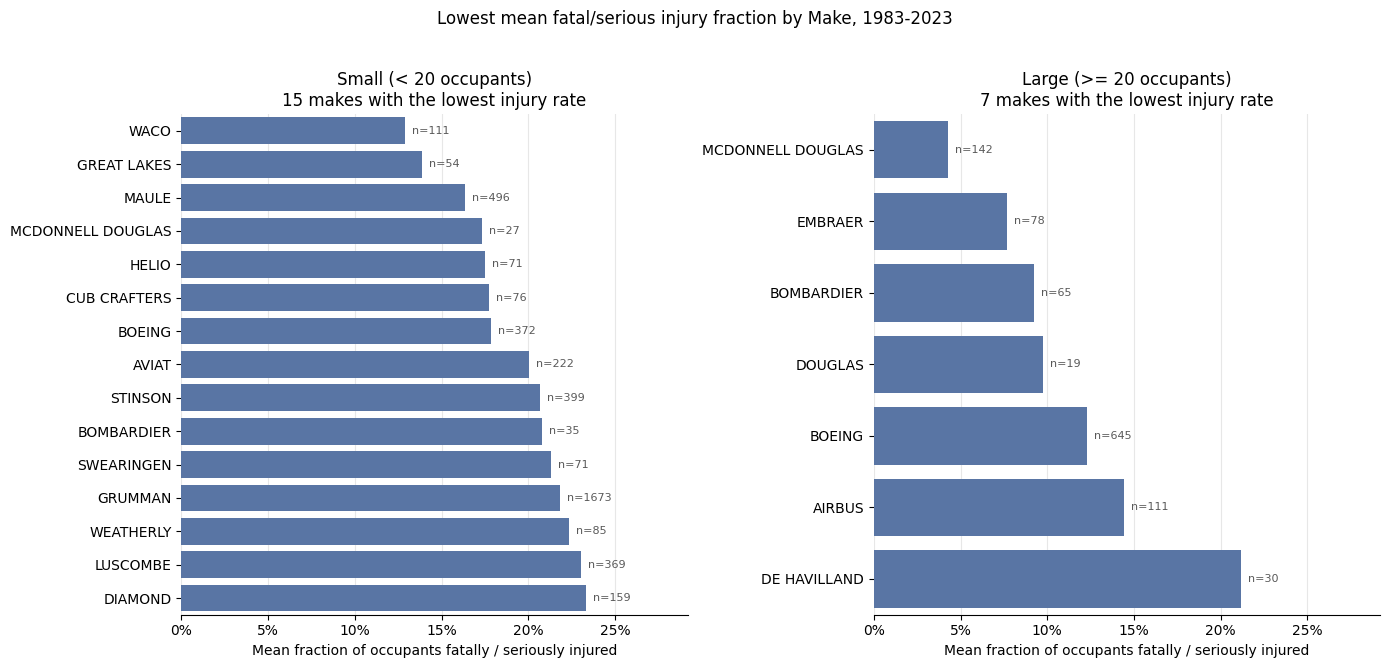

In [4]:
# --- Injury risk by Make: the 15 lowest mean fatal/serious fractions per size group ---

# A make's mean rate is only meaningful with enough accidents behind it, so require a
# minimum sample per make. The two groups can't share one bar: small planes have 142
# makes with >= 10 accidents, but the whole large-plane group only has 12, so a common
# threshold of 10 would leave the large panel short of the 15 makes asked for.
MIN_ACCIDENTS = {'Small (< 20 occupants)': 10, 'Large (>= 20 occupants)': 5}
N_MAKES = 15

groups = {'Small (< 20 occupants)': small_planes_df,
          'Large (>= 20 occupants)': large_planes_df}

lowest = {}
for label, data in groups.items():
    stats = (
        data.groupby('Make')['Fatal.Serious.Rate']
            .agg(mean_rate='mean', accidents='count')      # count skips NaN rates
    )
    eligible = stats[stats['accidents'] >= MIN_ACCIDENTS[label]]
    lowest[label] = eligible.nsmallest(N_MAKES, 'mean_rate')

    print(f"{label}: {data['Make'].nunique()} makes, "
          f"{len(eligible)} with >= {MIN_ACCIDENTS[label]} accidents, "
          f"showing the {len(lowest[label])} lowest")
    display(lowest[label].style.format({'mean_rate': '{:.1%}'}))

# Side-by-side, sharing an x-axis so the two panels are directly comparable
fig, axes = plt.subplots(1, 2, figsize=(14, 6.5), sharex=True)

for ax, (label, stats) in zip(axes, lowest.items()):
    sns.barplot(x=stats['mean_rate'], y=stats.index, color='#4C72B0', ax=ax)
    # sample size per bar: the ranking is only as good as the evidence behind it
    ax.bar_label(ax.containers[0],
                 labels=[f'  n={n}' for n in stats['accidents']],
                 fontsize=8, color='0.35')
    ax.set_title(f'{label}\n{len(stats)} makes with the lowest injury rate')
    ax.set_xlabel('Mean fraction of occupants fatally / seriously injured')
    ax.set_ylabel('')
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    ax.grid(axis='x', alpha=0.3)
    ax.set_axisbelow(True)
    sns.despine(ax=ax, left=True)

axes[0].set_xlim(0, max(s['mean_rate'].max() for s in lowest.values()) * 1.25)
fig.suptitle('Lowest mean fatal/serious injury fraction by Make, 1983-2023', y=1.02)
fig.tight_layout()
plt.show()

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

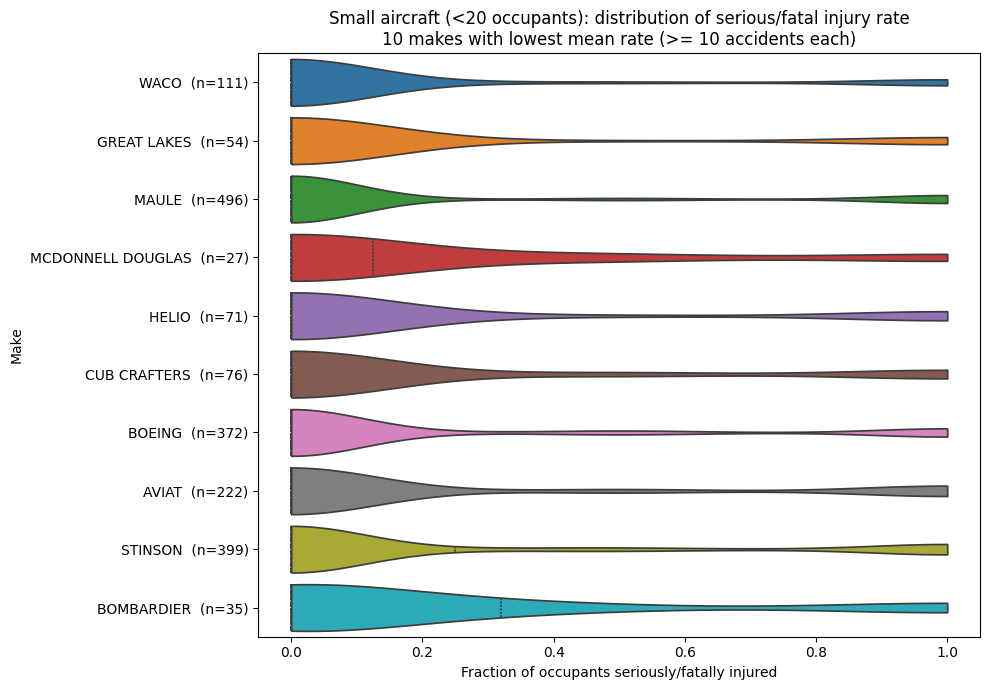

,mean_rate,n
Make,,
WACO,0.129129,111
GREAT LAKES,0.138889,54
MAULE,0.163239,496
MCDONNELL DOUGLAS,0.173280,27
HELIO,0.175096,71
CUB CRAFTERS,0.177632,76
BOEING,0.178457,372
AVIAT,0.200450,222
STINSON,0.206976,399


In [5]:
MIN_ACCIDENTS = 10

small_make_stats = (
    small_planes_df.groupby('Make')['Fatal.Serious.Rate']
    .agg(mean_rate='mean', n='count')
)
small_make_stats = small_make_stats[small_make_stats['n'] >= MIN_ACCIDENTS]

# Ten makes with the lowest mean serious/fatal injury rate
top10_small_makes = small_make_stats.sort_values('mean_rate').head(10)
make_order = top10_small_makes.index.tolist()

plot_df = small_planes_df[small_planes_df['Make'].isin(make_order)]

fig, ax = plt.subplots(figsize=(10, 7))
sns.violinplot(
    data=plot_df,
    x='Fatal.Serious.Rate',
    y='Make',
    order=make_order,
    hue='Make',
    hue_order=make_order,
    legend=False,
    cut=0,                    # rate is bounded [0, 1] -- don't smooth past the data
    density_norm='width',
    inner='quartile',
    ax=ax,
)
ax.set_xlim(-0.05, 1.05)
ax.set_xlabel('Fraction of occupants seriously/fatally injured')
ax.set_ylabel('Make')
ax.set_title(
    'Small aircraft (<20 occupants): distribution of serious/fatal injury rate\n'
    f'10 makes with lowest mean rate (>= {MIN_ACCIDENTS} accidents each)'
)
# annotate each make with its sample size
ax.set_yticks(range(len(make_order)))
ax.set_yticklabels([f'{m}  (n={top10_small_makes.loc[m, "n"]})' for m in make_order])
plt.tight_layout()
plt.show()

display(top10_small_makes)

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

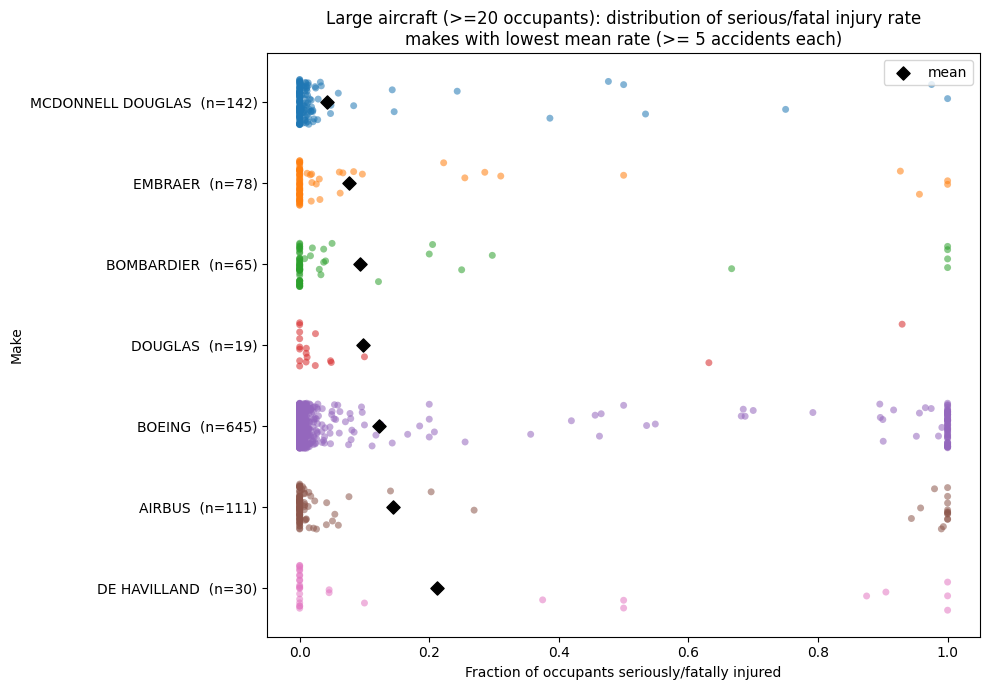

,mean_rate,n
Make,,
MCDONNELL DOUGLAS,0.042750,142
EMBRAER,0.076892,78
BOMBARDIER,0.092489,65
DOUGLAS,0.097263,19
BOEING,0.122955,645
AIRBUS,0.144314,111
DE HAVILLAND,0.211522,30


In [6]:
MIN_ACCIDENTS = 5

large_make_stats = (
    large_planes_df.groupby('Make')['Fatal.Serious.Rate']
    .agg(mean_rate='mean', n='count')          # count skips NaN rates
)
large_make_stats = large_make_stats[large_make_stats['n'] >= MIN_ACCIDENTS]

# Ten makes with the lowest mean serious/fatal injury rate
top10_large_makes = large_make_stats.nsmallest(10, 'mean_rate')
make_order = top10_large_makes.index.tolist()

plot_df = large_planes_df[large_planes_df['Make'].isin(make_order)]

fig, ax = plt.subplots(figsize=(10, 7))
sns.stripplot(
    data=plot_df,
    x='Fatal.Serious.Rate',
    y='Make',
    order=make_order,
    hue='Make',
    hue_order=make_order,
    legend=False,
    jitter=0.28,       # ~half the accidents have a rate of exactly 0 -- spread the pile-up
    alpha=0.55,
    size=5,
    ax=ax,
)
# mark each make's mean so the ordering of the rows is visible
ax.scatter(top10_large_makes['mean_rate'], range(len(make_order)),
           marker='D', s=45, color='black', zorder=5, label='mean')
ax.legend(loc='upper right', frameon=True)

ax.set_xlim(-0.05, 1.05)
ax.set_xlabel('Fraction of occupants seriously/fatally injured')
ax.set_ylabel('Make')
ax.set_title(
    'Large aircraft (>=20 occupants): distribution of serious/fatal injury rate\n'
    f'makes with lowest mean rate (>= {MIN_ACCIDENTS} accidents each)'
)
# annotate each make with its sample size
ax.set_yticks(range(len(make_order)))
ax.set_yticklabels([f'{m}  (n={top10_large_makes.loc[m, "n"]})' for m in make_order])
plt.tight_layout()
plt.show()

display(top10_large_makes)

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

Small (< 20 occupants): 47 makes, 46 with >= 10 accidents, showing the 15 lowest


,destroyed_rate,accidents,destroyed
Make,,,
CUB CRAFTERS,1.3%,76,1
AVIAT,6.3%,221,14
DIAMOND,7.5%,160,12
FLIGHT DESIGN,7.7%,78,6
AMERICAN CHAMPION,8.0%,87,7
WACO,9.0%,111,10
MAULE,9.3%,496,46
LUSCOMBE,10.1%,365,37
TAYLORCRAFT,10.9%,329,36


Large (>= 20 occupants): 9 makes, 7 with >= 5 accidents, showing the 7 lowest


,destroyed_rate,accidents,destroyed
Make,,,
EMBRAER,9.3%,43,4
BOMBARDIER,9.4%,53,5
MCDONNELL DOUGLAS,11.3%,106,12
DOUGLAS,12.5%,16,2
BOEING,19.4%,407,79
AIRBUS,25.4%,63,16
DE HAVILLAND,28.6%,28,8


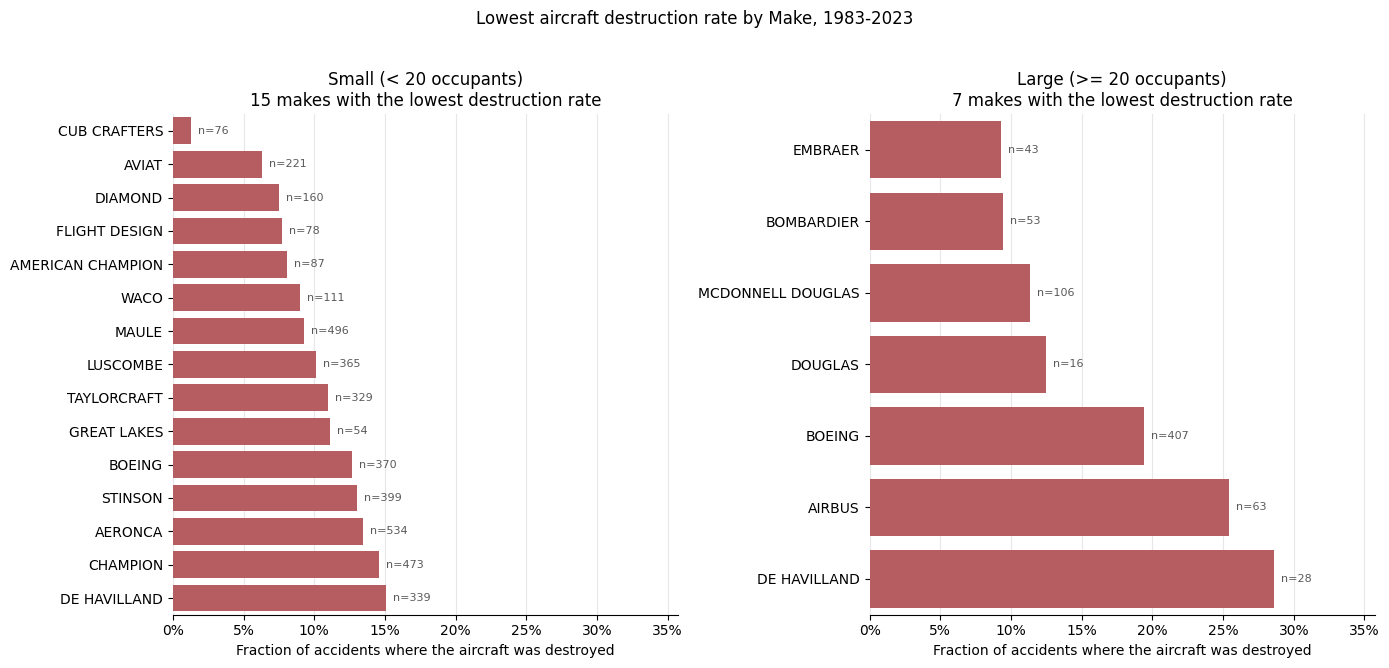

In [7]:
MIN_ACCIDENTS = {'Small (< 20 occupants)': 10, 'Large (>= 20 occupants)': 5}
N_MAKES = 15

groups = {'Small (< 20 occupants)': small_planes_df,
          'Large (>= 20 occupants)': large_planes_df}

lowest_destroyed = {}
for label, data in groups.items():
    stats = (
        data.groupby('Make')['Destroyed']
            .agg(destroyed_rate='mean', accidents='count', destroyed='sum')
    )
    eligible = stats[stats['accidents'] >= MIN_ACCIDENTS[label]]
    # Many makes tie at a 0% destruction rate, so break ties toward the make with the
    # most accidents behind that zero instead of letting alphabetical order decide.
    lowest_destroyed[label] = (
        eligible.sort_values(['destroyed_rate', 'accidents'], ascending=[True, False])
                .head(N_MAKES)
    )

    print(f"{label}: {data['Make'].nunique()} makes, "
          f"{len(eligible)} with >= {MIN_ACCIDENTS[label]} accidents, "
          f"showing the {len(lowest_destroyed[label])} lowest")
    display(lowest_destroyed[label].style.format({'destroyed_rate': '{:.1%}',
                                                  'destroyed': '{:.0f}'}))

fig, axes = plt.subplots(1, 2, figsize=(14, 6.5), sharex=True)

for ax, (label, stats) in zip(axes, lowest_destroyed.items()):
    sns.barplot(x=stats['destroyed_rate'], y=stats.index, color='#C44E52', ax=ax)
    ax.bar_label(ax.containers[0],
                 labels=[f'  n={n}' for n in stats['accidents']],
                 fontsize=8, color='0.35')
    ax.set_title(f'{label}\n{len(stats)} makes with the lowest destruction rate')
    ax.set_xlabel('Fraction of accidents where the aircraft was destroyed')
    ax.set_ylabel('')
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    ax.grid(axis='x', alpha=0.3)
    ax.set_axisbelow(True)
    sns.despine(ax=ax, left=True)

axes[0].set_xlim(0, max(s['destroyed_rate'].max() for s in lowest_destroyed.values()) * 1.25)
fig.suptitle('Lowest aircraft destruction rate by Make, 1983-2023', y=1.02)
fig.tight_layout()
plt.show()


#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

Larger planes are much safer for the people on board: on average 11.2% of occupants are
killed or seriously hurt, compared to 27.8% on small planes. The planes themselves are
destroyed at about the same rate either way (17.7% vs 21.0%), so size protects passengers
much more than it protects the aircraft.

The violin and strip plots show why the averages need care: most accidents have an injury
rate of exactly 0 (69% of small-plane accidents) and a further quarter have a rate of
exactly 1.0 (25%). Accidents are either harmless or catastrophic with little in between,
so a make's "average" is best read as how often its accidents turn out badly, not as a
typical outcome. The two safety measures do point the same direction — nine makes appear
on both lowest-15 lists.

**Small planes.** Maule is the strongest recommendation: 16.3% injury rate and 9.3%
destroyed, backed by 496 accidents — by far the largest evidence base of any make in the
low-risk group. Cub Crafters has the lowest destruction rate at 1.3%, and Aviat is second
at 6.3% with a much larger sample (n=221); Diamond follows at 7.5% (n=160) and is the only
modern composite make in the group, so it is the most relevant to a client who needs
aircraft still in production. Waco (12.9%, n=111) and Great Lakes (13.9%, n=54) lead on
injury rate but are open-cockpit biplanes flown recreationally at low speed — good numbers,
narrow applicability.

**Two makes in the small group need reading carefully.** Size class is inferred from the
75th percentile of occupants actually aboard, not from seating capacity, so *Boeing* here
is entirely Stearman biplanes (A75N1, B75N1, E75 — 1930s-40s trainers, not jets), and
*McDonnell Douglas* is 27 MD-11F/DC-9 **freighter** accidents flown with 2-3 crew. The
freighters are large aircraft that the occupancy heuristic misclassifies, and they should
be excluded from any small-aircraft recommendation. Bombardier in this group is
Challenger/BD-100 business jets, which genuinely are small by seat count.

**Large planes.** Only 7 of 9 makes reach even 5 accidents, so this ranking is inherently
thinner. Embraer (7.7% injury / 9.3% destroyed) and Bombardier (9.2% / 9.4%) are the top
picks — best on hull loss, near-best on injury, both in current production. McDonnell
Douglas posts the lowest injury rate of any make at 4.3% (n=142), but its airframes are
all out of production since 1997 and sit at the edge of the client's own 40-year activity
assumption, so it is a historical result rather than a purchasing recommendation. Airbus
(14.4% / 25.4%) and De Havilland (21.2% / 28.6%) performed worst on both measures.

**Caveat.** Several makes rest on small samples, so rankings could shift with a few more
accidents. More importantly, every number here describes how bad an accident was *once it
happened*. There is no flight-hour or departure denominator in this dataset, so nothing
here says which aircraft are more likely to crash in the first place.


### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

Large aircraft: 269 types, 27 with >= 10 accidents, showing the 15 lowest


,mean_rate,median_rate,std_rate,pooled_rate,destroyed_rate,n
Make_Model,,,,,,
BOEING 777,0.2%,0.0%,0.004,0.2%,11.1%,15
BOEING 717-200,0.2%,0.0%,0.004,0.2%,0.0%,10
BOEING 757-232,0.5%,0.5%,0.006,0.5%,0.0%,16
MCDONNELL DOUGLAS MD-88,0.6%,0.0%,0.009,0.7%,0.0%,14
BOEING 757-222,0.7%,0.0%,0.012,0.3%,0.0%,11
BOEING 737-7H4,2.5%,0.4%,0.062,0.5%,0.0%,10
BOEING 747-400,5.0%,0.0%,0.182,3.3%,8.3%,14
BOEING 727-200,5.3%,0.7%,0.212,3.3%,9.1%,22
EMBRAER EMB-145LR,5.3%,0.0%,0.137,1.4%,0.0%,13


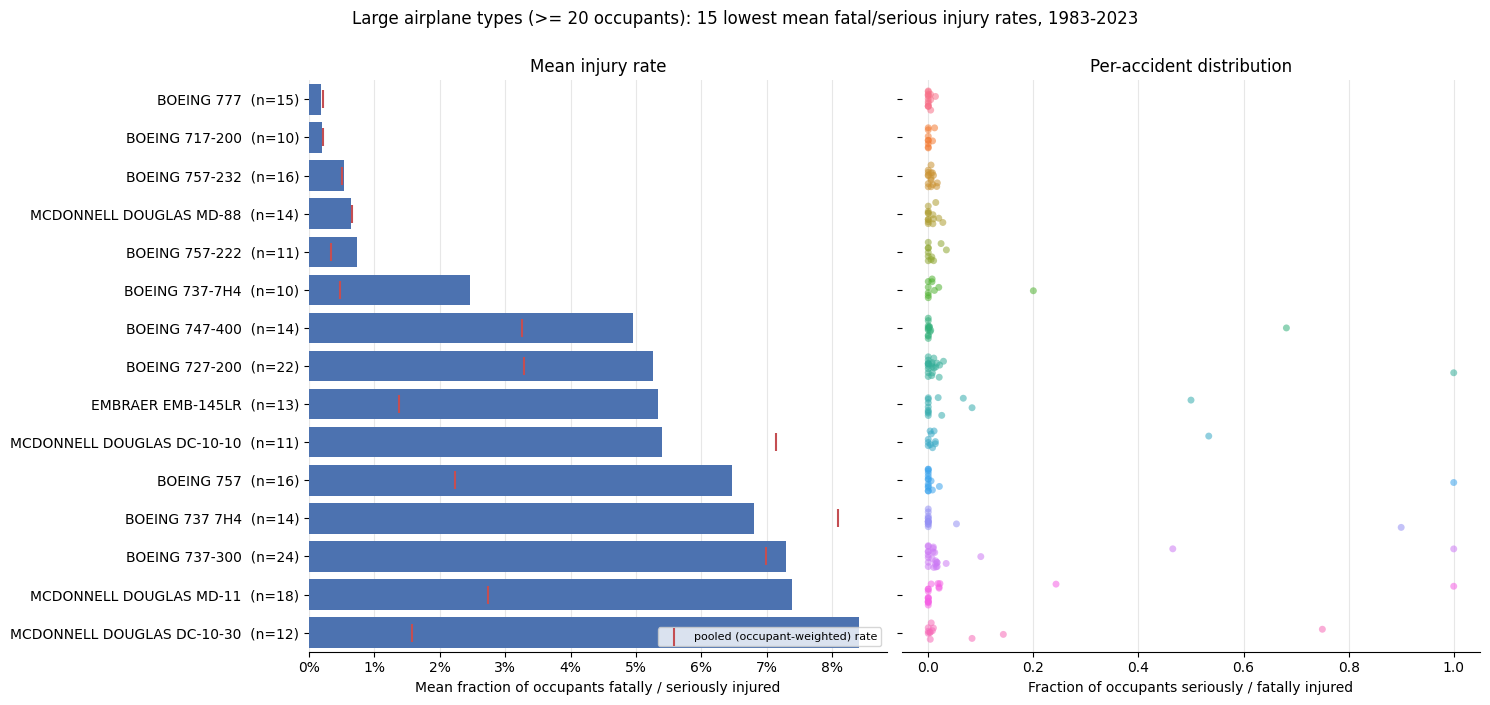


Share of accidents where nobody was seriously or fatally hurt:
Make_Model
BOEING 777                    0.58
BOEING 717-200                0.80
BOEING 757-232                0.38
MCDONNELL DOUGLAS MD-88       0.57
BOEING 757-222                0.55
BOEING 737-7H4                0.45
BOEING 747-400                0.53
BOEING 727-200                0.41
EMBRAER EMB-145LR             0.62
MCDONNELL DOUGLAS DC-10-10    0.27
BOEING 757                    0.60
BOEING 737 7H4                0.86
BOEING 737-300                0.32
MCDONNELL DOUGLAS MD-11       0.58
MCDONNELL DOUGLAS DC-10-30    0.25


In [8]:
# --- Injury risk by airplane TYPE (Make_Model): large aircraft ---
MIN_ACCIDENTS = 10
N_TYPES = 15

large_type_stats = (
    large_planes_df.groupby('Make_Model')
    .agg(mean_rate=('Fatal.Serious.Rate', 'mean'),
         median_rate=('Fatal.Serious.Rate', 'median'),
         std_rate=('Fatal.Serious.Rate', 'std'),
         n=('Fatal.Serious.Rate', 'count'),          # count skips NaN rates
         occupants=('Total.Occupants', 'sum'),
         fatal_serious=('Fatal.Serious.Injuries', 'sum'),
         destroyed_rate=('Destroyed', 'mean'))
)
# The pooled rate weights each accident by how many people were aboard, so one
# 180-seat accident doesn't count the same as one 25-seat accident. Where it
# disagrees with the mean, the mean is being driven by lightly loaded flights.
large_type_stats['pooled_rate'] = (
    large_type_stats['fatal_serious'] / large_type_stats['occupants']
)

eligible = large_type_stats[large_type_stats['n'] >= MIN_ACCIDENTS]
lowest_large = eligible.nsmallest(N_TYPES, 'mean_rate')

print(f"Large aircraft: {large_planes_df['Make_Model'].nunique()} types, "
      f"{len(eligible)} with >= {MIN_ACCIDENTS} accidents, "
      f"showing the {len(lowest_large)} lowest")
display(lowest_large[['mean_rate', 'median_rate', 'std_rate', 'pooled_rate',
                      'destroyed_rate', 'n']]
        .style.format({'mean_rate': '{:.1%}', 'median_rate': '{:.1%}',
                       'std_rate': '{:.3f}', 'pooled_rate': '{:.1%}',
                       'destroyed_rate': '{:.1%}'}))

order = lowest_large.index.tolist()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7), sharey=True)
y = np.arange(len(order))

ax1.barh(y, lowest_large['mean_rate'], color='#4C72B0')
ax1.scatter(lowest_large['pooled_rate'], y, marker='|', s=180, color='#C44E52',
            zorder=5, label='pooled (occupant-weighted) rate')
ax1.set_yticks(y)
ax1.set_yticklabels([f'{t}  (n={lowest_large.loc[t, "n"]})' for t in order])
ax1.invert_yaxis()
ax1.legend(loc='lower right', fontsize=8)
ax1.set_xlabel('Mean fraction of occupants fatally / seriously injured')
ax1.set_title('Mean injury rate')
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax1.grid(axis='x', alpha=0.3)
ax1.set_axisbelow(True)

plot_df = large_planes_df[large_planes_df['Make_Model'].isin(order)]
sns.stripplot(data=plot_df, x='Fatal.Serious.Rate', y='Make_Model', order=order,
              hue='Make_Model', hue_order=order, legend=False,
              jitter=0.3, alpha=0.55, size=5, ax=ax2)
ax2.set_xlim(-0.05, 1.05)
ax2.set_xlabel('Fraction of occupants seriously / fatally injured')
ax2.set_ylabel('')
ax2.set_title('Per-accident distribution')
ax2.grid(axis='x', alpha=0.3)
ax2.set_axisbelow(True)

fig.suptitle(f'Large airplane types (>= {PASSENGER_THRESHOLD} occupants): '
             f'{N_TYPES} lowest mean fatal/serious injury rates, 1983-2023', y=1.0)
sns.despine(ax=ax1, left=True)
sns.despine(ax=ax2, left=True)
fig.tight_layout()
plt.show()

# The means are small because most accidents hurt nobody -- quantify that directly
zero_share = plot_df.groupby('Make_Model')['Fatal.Serious.Rate'].apply(lambda s: (s == 0).mean())
print('\nShare of accidents where nobody was seriously or fatally hurt:')
print(zero_share.reindex(order).round(2).to_string())


**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

Types from the 10 lowest-injury small makes: 287 total, 40 with >= 10 accidents, showing the 15 lowest


,mean_rate,median_rate,std_rate,pooled_rate,destroyed_rate,n
Make_Model,,,,,,
MAULE MX-7-235,2.9%,0.0%,0.121,4.0%,0.0%,17
MAULE M-7-235B,5.0%,0.0%,0.158,5.0%,0.0%,10
MAULE M-4,5.6%,0.0%,0.236,15.8%,5.6%,18
BOEING E75,6.2%,0.0%,0.232,4.3%,10.0%,40
WACO YMF,8.3%,0.0%,0.180,8.7%,0.0%,10
MAULE M-4-220C,10.8%,0.0%,0.292,7.7%,8.1%,37
STINSON 108-1,11.0%,0.0%,0.287,11.4%,14.1%,85
GREAT LAKES 2T-1A-2,11.5%,0.0%,0.313,11.1%,12.8%,39
MAULE MX7,12.5%,0.0%,0.300,19.2%,0.0%,18


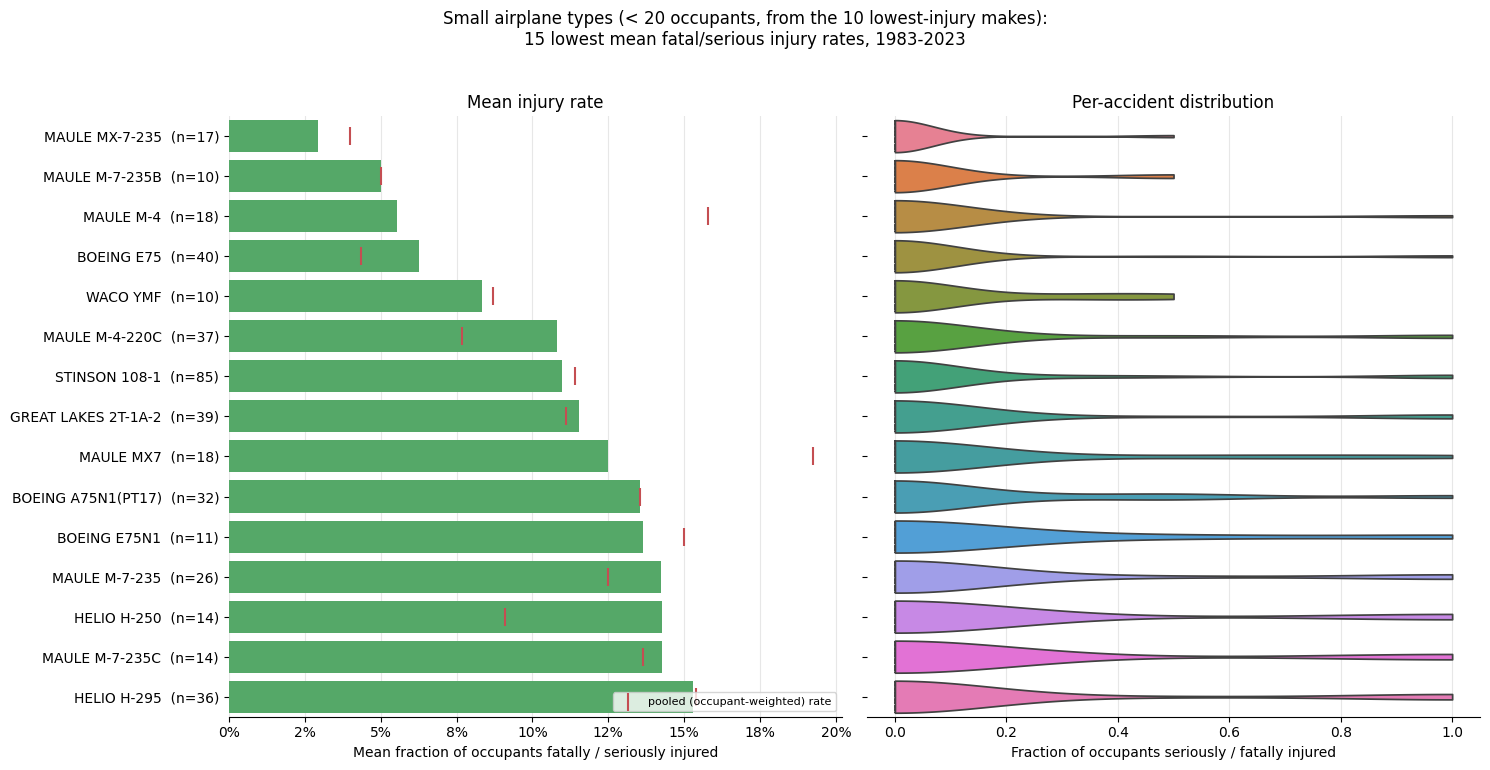


Share of accidents where nobody was seriously or fatally hurt:
Make_Model
MAULE MX-7-235         0.94
MAULE M-7-235B         0.90
MAULE M-4              0.94
BOEING E75             0.92
WACO YMF               0.80
MAULE M-4-220C         0.86
STINSON 108-1          0.85
GREAT LAKES 2T-1A-2    0.87
MAULE MX7              0.83
BOEING A75N1(PT17)     0.78
BOEING E75N1           0.82
MAULE M-7-235          0.81
HELIO H-250            0.86
MAULE M-7-235C         0.86
HELIO H-295            0.83


In [9]:
# --- Injury risk by airplane TYPE (Make_Model): small aircraft ---
# Limited to the 10 makes with the lowest mean injury rate, as asked.
MIN_ACCIDENTS = 10
N_TYPES = 15

# Re-derived here so this cell doesn't depend on variables from an earlier one
make_rates = (small_planes_df.groupby('Make')['Fatal.Serious.Rate']
              .agg(mean_rate='mean', n='count'))
top10_small_makes = make_rates[make_rates['n'] >= MIN_ACCIDENTS].nsmallest(10, 'mean_rate')

small_type_stats = (
    small_planes_df[small_planes_df['Make'].isin(top10_small_makes.index)]
    .groupby('Make_Model')
    .agg(mean_rate=('Fatal.Serious.Rate', 'mean'),
         median_rate=('Fatal.Serious.Rate', 'median'),
         std_rate=('Fatal.Serious.Rate', 'std'),
         n=('Fatal.Serious.Rate', 'count'),
         occupants=('Total.Occupants', 'sum'),
         fatal_serious=('Fatal.Serious.Injuries', 'sum'),
         destroyed_rate=('Destroyed', 'mean'))
)
small_type_stats['pooled_rate'] = (
    small_type_stats['fatal_serious'] / small_type_stats['occupants']
)

eligible = small_type_stats[small_type_stats['n'] >= MIN_ACCIDENTS]
lowest_small = eligible.nsmallest(N_TYPES, 'mean_rate')

print(f"Types from the 10 lowest-injury small makes: {len(small_type_stats)} total, "
      f"{len(eligible)} with >= {MIN_ACCIDENTS} accidents, "
      f"showing the {len(lowest_small)} lowest")
display(lowest_small[['mean_rate', 'median_rate', 'std_rate', 'pooled_rate',
                      'destroyed_rate', 'n']]
        .style.format({'mean_rate': '{:.1%}', 'median_rate': '{:.1%}',
                       'std_rate': '{:.3f}', 'pooled_rate': '{:.1%}',
                       'destroyed_rate': '{:.1%}'}))

order = lowest_small.index.tolist()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7.5), sharey=True)
y = np.arange(len(order))

ax1.barh(y, lowest_small['mean_rate'], color='#55A868')
ax1.scatter(lowest_small['pooled_rate'], y, marker='|', s=180, color='#C44E52',
            zorder=5, label='pooled (occupant-weighted) rate')
ax1.set_yticks(y)
ax1.set_yticklabels([f'{t}  (n={lowest_small.loc[t, "n"]})' for t in order])
ax1.invert_yaxis()
ax1.legend(loc='lower right', fontsize=8)
ax1.set_xlabel('Mean fraction of occupants fatally / seriously injured')
ax1.set_title('Mean injury rate')
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax1.grid(axis='x', alpha=0.3)
ax1.set_axisbelow(True)

plot_df = small_planes_df[small_planes_df['Make_Model'].isin(order)]
sns.violinplot(data=plot_df, x='Fatal.Serious.Rate', y='Make_Model', order=order,
               hue='Make_Model', hue_order=order, legend=False,
               cut=0,                    # rate is bounded [0, 1] -- don't smooth past it
               density_norm='width', inner='quartile', ax=ax2)
ax2.set_xlim(-0.05, 1.05)
ax2.set_xlabel('Fraction of occupants seriously / fatally injured')
ax2.set_ylabel('')
ax2.set_title('Per-accident distribution')
ax2.grid(axis='x', alpha=0.3)
ax2.set_axisbelow(True)

fig.suptitle(f'Small airplane types (< {PASSENGER_THRESHOLD} occupants, from the 10 '
             f'lowest-injury makes):\n{N_TYPES} lowest mean fatal/serious injury '
             f'rates, 1983-2023', y=1.02)
sns.despine(ax=ax1, left=True)
sns.despine(ax=ax2, left=True)
fig.tight_layout()
plt.show()

# The violins are dominated by a spike at zero -- quantify it directly
zero_share = plot_df.groupby('Make_Model')['Fatal.Serious.Rate'].apply(lambda s: (s == 0).mean())
print('\nShare of accidents where nobody was seriously or fatally hurt:')
print(zero_share.reindex(order).round(2).to_string())


### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

**Large types.** Of 269 large plane types only 27 reach 10 accidents, so this list is short
by necessity. The Boeing 777 (0.2%), 717-200 (0.2%), 757-232 (0.5%) and McDonnell Douglas
MD-88 (0.6%) have the lowest injury rates; the Boeing 737-200 (37.5%) and Airbus A320
(37.3%) are the worst.

**The two client criteria disagree at the very top of this list.** The 777 has the lowest
injury rate in the dataset but destroyed the airframe in 11.1% of its accidents — the
highest of the leading group — while the 757-232, 757-222, 717-200 and MD-88 all sit at
0.0% destroyed. On the client's combined criteria the **757 family, 717-200 and MD-88**
are the better recommendation, and the 777 is a useful illustration that ranking first on
occupant safety does not mean ranking first on hull loss.

**Small types.** Restricting to the 10 lowest-injury makes leaves 40 types with at least
10 accidents, spread across 8 makes. The result is strikingly concentrated: six of the
fifteen best are Maule variants (MX-7-235 2.9%, M-7-235B 5.0%, M-4 5.6%, M-4-220C 10.8%,
MX7 12.5%, M-7-235 14.2%), joined by the Boeing E75 and A75N1 Stearmans (6.2% and 13.5%),
the Waco YMF (8.3%), the Stinson 108-1 (11.0%, n=85 — the largest sample in the group) and
the Great Lakes 2T-1A-2 (11.5%). Maule appearing repeatedly rather than once makes the
result far more believable than a single lucky model would be.

The median injury rate is 0.0 for **every** type in both lists, so these averages are
driven entirely by a minority of severe accidents. With only 10-40 accidents per type and
standard deviations of 0.12-0.36, one severe accident moves a model several places; the
gap between Maule MX-7-235 at 2.9% and Maule M-4 at 5.6% is not meaningful. Claims are
safest at the make or family level. This is especially true for small aircraft, where most
accidents involve one or two people aboard, so the injury fraction can only land on a few
coarse values (0, 0.5, 1).

**Recommendation:** the Boeing 757 family and 717-200 for large aircraft, and the Maule
M-4/M-7/MX-7 series for small ones, with the Stinson 108-1 as the next best-evidenced
single type.


### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

`Weather.Condition` splits accidents into **VMC** (visual meteorological conditions — the pilot can see) and **IMC** (instrument conditions — cloud, fog, low visibility, so the aircraft must be flown on instruments).

The question is whether the *conditions* an accident happens in change how bad the outcome is, independent of what airframe is involved. I compare both outcome measures — `Destroyed` (airframe written off) and `Fatal.Serious.Rate` (fraction of occupants killed or seriously hurt) — across the two weather categories, then check two things that could be driving a false impression: whether the gap is really just a phase-of-flight effect in disguise, and whether it shows up for both small and large aircraft.


53,680 of 56,302 accidents have a recorded weather condition (4.7% missing)

Counts:


Aircraft.damage,Minor,Substantial,Destroyed
Weather,,,
VMC (visual),331,40427,8057
IMC (instrument),16,1730,2572



Share of each weather group:


Aircraft.damage,Minor,Substantial,Destroyed
Weather,,,
VMC (visual),0.7%,82.8%,16.5%
IMC (instrument),0.4%,40.1%,59.6%


,accidents,destroyed_rate,mean_injury_rate,median_injury_rate,std_injury_rate,pooled_injury_rate
Weather,,,,,,
VMC (visual),"49,279",16.5%,22.4%,0.0%,0.400,14.9%
IMC (instrument),"4,401",59.6%,67.5%,100.0%,0.453,33.7%



IMC vs VMC: 3.6x the destruction rate, 3.0x the mean injury rate


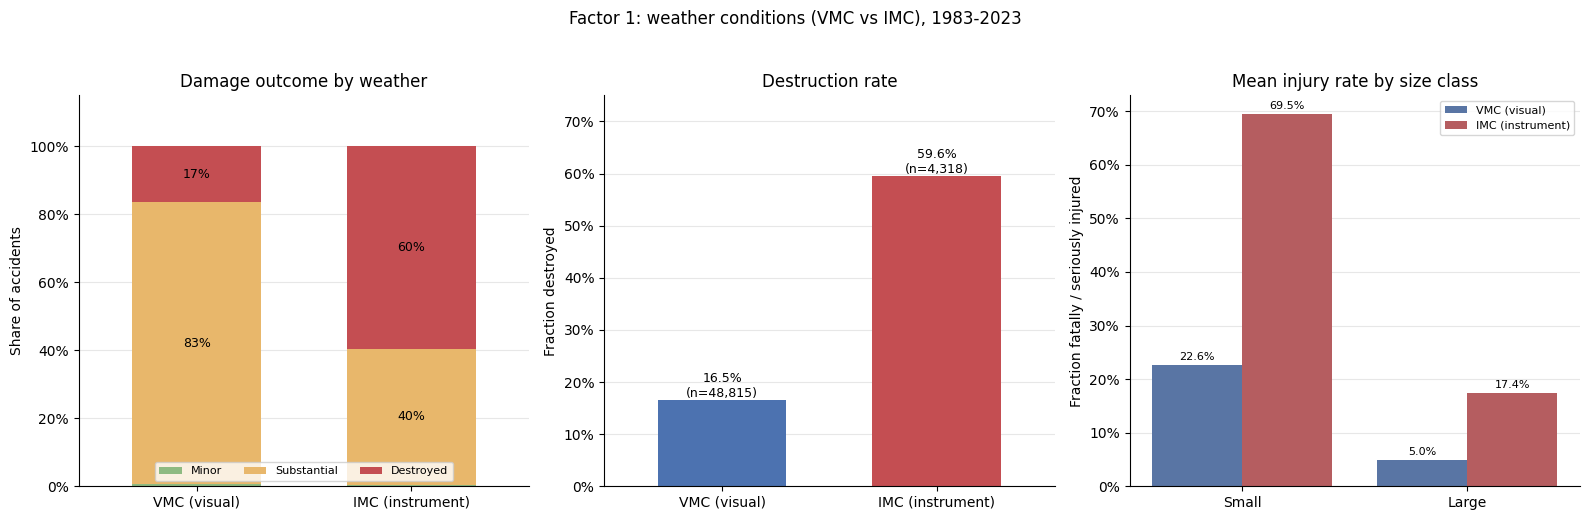

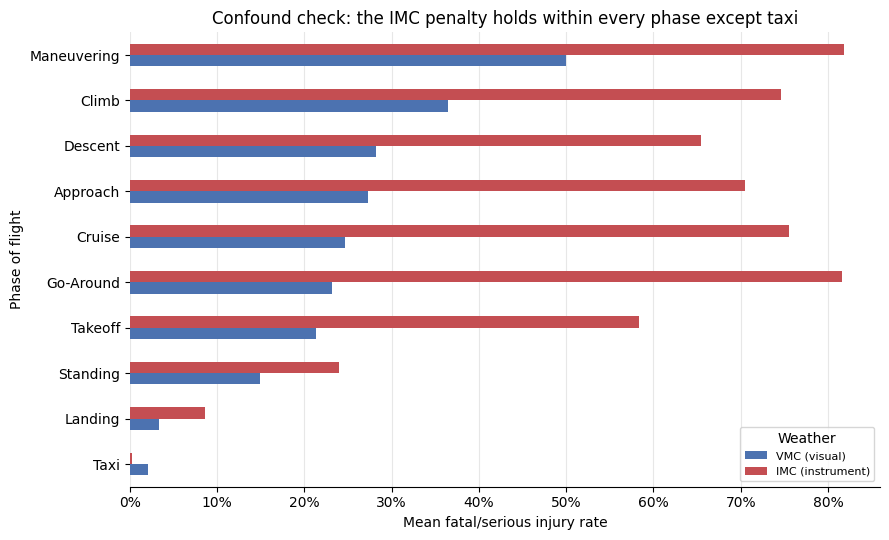

Mean fatal/serious injury rate by phase and weather:


Weather,VMC (visual),IMC (instrument)
Broad.phase.of.flight,,
Taxi,2.1%,0.3%
Landing,3.4%,8.6%
Standing,14.9%,23.9%
Takeoff,21.3%,58.4%
Go-Around,23.2%,81.6%
Cruise,24.6%,75.6%
Approach,27.2%,70.5%
Descent,28.2%,65.4%
Climb,36.4%,74.6%



Where accidents happen, by weather (% of that weather group):


Broad.phase.of.flight,Landing,Takeoff,Cruise,Approach,Maneuvering
Weather,,,,,
VMC (visual),30.0%,21.8%,14.6%,9.4%,11.0%
IMC (instrument),7.3%,9.4%,35.4%,22.4%,9.4%


In [10]:
# --- Factor 1: weather condition (VMC vs IMC) ---
DAMAGE_ORDER = ['Minor', 'Substantial', 'Destroyed']
WX_ORDER = ['VMC (visual)', 'IMC (instrument)']

wx = df[df['Weather.Condition'].isin(['VMC', 'IMC'])].copy()
wx['Weather'] = wx['Weather.Condition'].map({'VMC': 'VMC (visual)',
                                             'IMC': 'IMC (instrument)'})
print(f"{len(wx):,} of {len(df):,} accidents have a recorded weather condition "
      f"({df['Weather.Condition'].isna().mean():.1%} missing)\n")

# How the damage outcome splits within each weather group
damage_counts = (pd.crosstab(wx['Weather'], wx['Aircraft.damage'])
                 .reindex(index=WX_ORDER, columns=DAMAGE_ORDER))
damage_share = (pd.crosstab(wx['Weather'], wx['Aircraft.damage'], normalize='index')
                .reindex(index=WX_ORDER, columns=DAMAGE_ORDER))
print("Counts:")
display(damage_counts)
print("\nShare of each weather group:")
display(damage_share.style.format('{:.1%}'))

# Central tendency AND dispersion -- the mean alone hides how split the outcomes are
wx_stats = wx.groupby('Weather').agg(
    accidents=('Weather', 'size'),
    destroyed_rate=('Destroyed', 'mean'),
    known_damage=('Destroyed', 'count'),
    mean_injury_rate=('Fatal.Serious.Rate', 'mean'),
    median_injury_rate=('Fatal.Serious.Rate', 'median'),
    std_injury_rate=('Fatal.Serious.Rate', 'std'),
    fatal_serious=('Fatal.Serious.Injuries', 'sum'),
    occupants=('Total.Occupants', 'sum')).reindex(WX_ORDER)
# Pooled rate weights each accident by how many people were aboard
wx_stats['pooled_injury_rate'] = wx_stats['fatal_serious'] / wx_stats['occupants']

display(wx_stats[['accidents', 'destroyed_rate', 'mean_injury_rate', 'median_injury_rate',
                  'std_injury_rate', 'pooled_injury_rate']]
        .style.format({'accidents': '{:,.0f}', 'destroyed_rate': '{:.1%}',
                       'mean_injury_rate': '{:.1%}', 'median_injury_rate': '{:.1%}',
                       'std_injury_rate': '{:.3f}', 'pooled_injury_rate': '{:.1%}'}))

ratio_d = (wx_stats.loc['IMC (instrument)', 'destroyed_rate']
           / wx_stats.loc['VMC (visual)', 'destroyed_rate'])
ratio_i = (wx_stats.loc['IMC (instrument)', 'mean_injury_rate']
           / wx_stats.loc['VMC (visual)', 'mean_injury_rate'])
print(f"\nIMC vs VMC: {ratio_d:.1f}x the destruction rate, "
      f"{ratio_i:.1f}x the mean injury rate")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

damage_share.plot(kind='bar', stacked=True, ax=axes[0], width=0.6,
                  color=['#8EBA82', '#E8B76B', '#C44E52'])
axes[0].set_title('Damage outcome by weather')
axes[0].set_xlabel('')
axes[0].set_ylabel('Share of accidents')
axes[0].set_ylim(0, 1.15)
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(fontsize=8, loc='lower center', ncol=3)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
for cont in axes[0].containers:
    axes[0].bar_label(cont, labels=[f'{v:.0%}' if v > 0.03 else '' for v in cont.datavalues],
                      label_type='center', fontsize=9)

wx_stats['destroyed_rate'].plot(kind='bar', ax=axes[1], width=0.6,
                                color=['#4C72B0', '#C44E52'])
axes[1].bar_label(axes[1].containers[0],
                  labels=[f'{v:.1%}\n(n={n:,})' for v, n in
                          zip(wx_stats['destroyed_rate'], wx_stats['known_damage'])],
                  fontsize=9)
axes[1].set_title('Destruction rate')
axes[1].set_ylabel('Fraction destroyed')
axes[1].set_xlabel('')
axes[1].set_ylim(0, 0.75)
axes[1].tick_params(axis='x', rotation=0)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

sns.barplot(data=wx, x='Size.Class', y='Fatal.Serious.Rate', hue='Weather',
            hue_order=WX_ORDER, order=['Small', 'Large'], errorbar=None,
            palette=['#4C72B0', '#C44E52'], ax=axes[2])
axes[2].set_title('Mean injury rate by size class')
axes[2].set_ylabel('Fraction fatally / seriously injured')
axes[2].set_xlabel('')
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
axes[2].legend(fontsize=8, title=None)
for cont in axes[2].containers:
    axes[2].bar_label(cont, labels=[f'{v:.1%}' for v in cont.datavalues],
                      fontsize=8, padding=2)

for ax in axes:
    ax.grid(axis='y', alpha=0.3)
    ax.set_axisbelow(True)
    sns.despine(ax=ax)
fig.suptitle('Factor 1: weather conditions (VMC vs IMC), 1983-2023', y=1.03)
fig.tight_layout()
plt.show()

# Does the pattern survive inside each size class, or is it just a small-plane effect?
display(wx.groupby(['Size.Class', 'Weather']).agg(
    accidents=('Weather', 'size'),
    destroyed_rate=('Destroyed', 'mean'),
    mean_injury_rate=('Fatal.Serious.Rate', 'mean'),
    median_injury_rate=('Fatal.Serious.Rate', 'median'))
    .reindex(pd.MultiIndex.from_product([['Small', 'Large'], WX_ORDER]))
    .style.format({'accidents': '{:,.0f}', 'destroyed_rate': '{:.1%}',
                   'mean_injury_rate': '{:.1%}', 'median_injury_rate': '{:.1%}'}))

# Confound check: IMC accidents cluster in phases that are already dangerous,
# so compare within phase before crediting the whole gap to weather itself.
by_phase = (wx.dropna(subset=['Broad.phase.of.flight'])
              .pivot_table(index='Broad.phase.of.flight', columns='Weather',
                           values='Fatal.Serious.Rate', aggfunc='mean')
              .reindex(columns=WX_ORDER)
              .sort_values('VMC (visual)'))

fig, ax = plt.subplots(figsize=(9, 5.5))
by_phase.plot(kind='barh', color=['#4C72B0', '#C44E52'], ax=ax)
ax.set(xlabel='Mean fatal/serious injury rate', ylabel='Phase of flight',
       title='Confound check: the IMC penalty holds within every phase except taxi')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend(title='Weather', fontsize=8)
ax.grid(axis='x', alpha=0.3)
ax.set_axisbelow(True)
sns.despine(ax=ax, left=True)
plt.tight_layout()
plt.show()

print('Mean fatal/serious injury rate by phase and weather:')
display(by_phase.style.format('{:.1%}', na_rep='-'))

# How much of the raw gap is just a difference in where accidents happen?
phase_mix = (wx.dropna(subset=['Broad.phase.of.flight'])
               .groupby('Weather')['Broad.phase.of.flight']
               .value_counts(normalize=True).unstack().reindex(WX_ORDER) * 100)
print('\nWhere accidents happen, by weather (% of that weather group):')
display(phase_mix[['Landing', 'Takeoff', 'Cruise', 'Approach', 'Maneuvering']]
        .style.format('{:.1f}%'))


Weather condition (VMC vs. IMC) is the single strongest signal in the data.

Weather is recorded for 53,680 of 56,302 accidents (4.7% missing), and only 8.2% of
those happened in instrument conditions — but that small minority accounts for a
wildly disproportionate share of the bad outcomes:

| | VMC (visual) | IMC (instrument) |
|---|---|---|
| Accidents | 49,279 | 4,401 |
| Aircraft destroyed | **16.5%** | **59.6%** |
| Mean fraction of occupants killed/seriously hurt | **22.4%** | **67.5%** |
| **Median** fraction killed/seriously hurt | **0.00** | **1.00** |
| Std. dev. of that fraction | 0.400 | 0.453 |
| Occupant-weighted (pooled) rate | 14.9% | 33.7% |

An accident in instrument conditions is **3.6× more likely to destroy the aircraft**
and injures **3.0×** the fraction of people aboard.

**Confound check.** IMC accidents are not distributed like VMC ones: 35.4% happen in
cruise and 22.4% on approach, against 14.6% and 9.4% for VMC, while only 7.3% are
landings versus 30.0%. Since cruise and approach are already severe phases, some of
the raw gap is a difference in *where* accidents happen rather than in the weather.
But comparing within each phase, the IMC penalty survives everywhere except taxi:
takeoff 21.3% → 58.4%, go-around 23.2% → 81.6%, cruise 24.6% → 75.6%, maneuvering
50.0% → 81.9%. Taxi is the single reversal (2.1% → 0.3%), on a small IMC sample and
in the one phase where visibility carries almost no energy penalty.

`Broad.phase.of.flight` records what the aircraft was doing when the accident occurred. Unlike weather, this is essentially a stand-in for **how much speed and altitude the aircraft had** when things went wrong, so I'd expect it to move damage and injury together.

I look at three things per phase: how often accidents happen there, how severe the injuries are, and how often the airframe is destroyed — and I keep only phases with at least 100 accidents so no rate is built on a tiny sample.


16,850 of 56,302 accidents (29.9%) have no phase recorded.
The field is populated only through 2007: 96.4% of the 40,908 accidents in 1983-2007 have it, and 0% of those after.

Phases with >= 100 accidents: 10 of 10


,accidents,share_of_accidents,destroyed_rate,mean_injury_rate,median_injury_rate,std_injury_rate,pooled_injury_rate
Broad.phase.of.flight,,,,,,,
Maneuvering,"4,277",10.8%,46.8%,52.7%,100.0%,0.487,55.3%
Climb,"1,257",3.2%,44.3%,43.7%,0.0%,0.477,22.6%
Cruise,"6,579",16.7%,34.5%,35.3%,0.0%,0.465,23.2%
Descent,"1,190",3.0%,33.6%,33.8%,0.0%,0.459,9.8%
Approach,"4,141",10.5%,30.0%,35.4%,0.0%,0.460,33.0%
Go-Around,"1,097",2.8%,28.5%,29.9%,0.0%,0.440,34.6%
Takeoff,"8,118",20.6%,21.7%,22.8%,0.0%,0.403,21.0%
Standing,520,1.3%,13.1%,15.3%,0.0%,0.285,3.1%
Landing,"10,984",27.8%,4.3%,3.6%,0.0%,0.172,3.7%


Range across phases: Maneuvering destroys the aircraft in 46.8% of accidents vs 2.1% for Taxi -- a spread of 44.7%
Most common phase: Landing (10,984 accidents, 27.8% of the total)


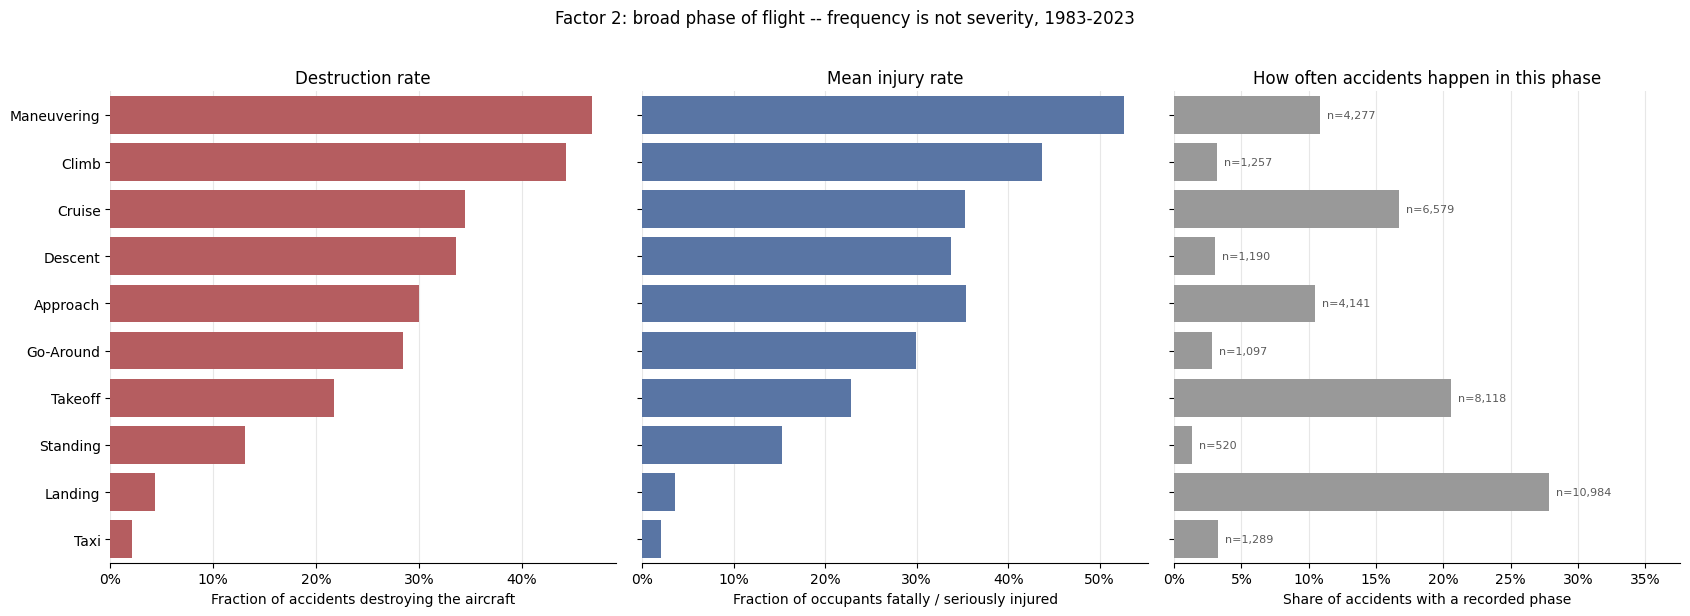

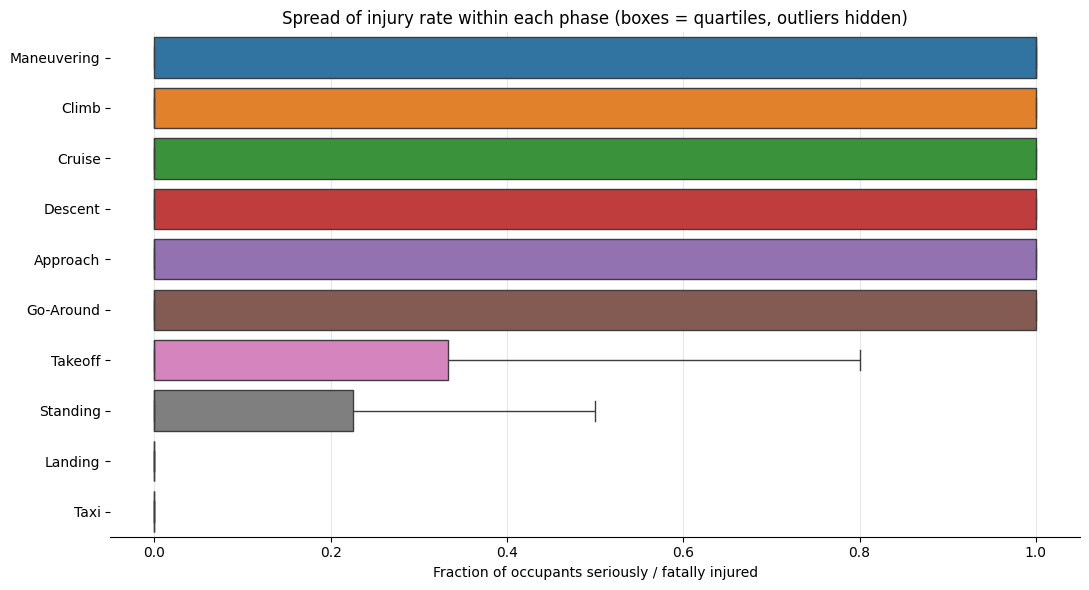


Missing-phase check -- destroyed rate 15.7% (missing) vs 23.1% (recorded); mean injury rate 34.6% vs 24.5%
Median event year: missing 2014 vs recorded 1993


In [11]:
# 30% of rows are missing this field -- check whether the gaps are spread over time
coverage = (df.assign(year=pd.to_datetime(df['Event.Date']).dt.year)
              .groupby('year')['Broad.phase.of.flight'].apply(lambda s: s.notna().mean()))
last_year = coverage[coverage > 0].index.max()
covered = df[pd.to_datetime(df['Event.Date']).dt.year <= last_year]
print(f"{df['Broad.phase.of.flight'].isna().sum():,} of {len(df):,} accidents "
      f"({df['Broad.phase.of.flight'].isna().mean():.1%}) have no phase recorded.")
print(f"The field is populated only through {last_year}: "
      f"{covered['Broad.phase.of.flight'].notna().mean():.1%} of the {len(covered):,} "
      f"accidents in 1983-{last_year} have it, and 0% of those after.\n")

ph = df[df['Broad.phase.of.flight'].notna()].copy()
MIN_ACCIDENTS = 100          # no rate built on a tiny sample

phase_stats = ph.groupby('Broad.phase.of.flight').agg(
    accidents=('Broad.phase.of.flight', 'size'),
    destroyed_rate=('Destroyed', 'mean'),
    mean_injury_rate=('Fatal.Serious.Rate', 'mean'),
    median_injury_rate=('Fatal.Serious.Rate', 'median'),
    std_injury_rate=('Fatal.Serious.Rate', 'std'),
    fatal_serious=('Fatal.Serious.Injuries', 'sum'),
    occupants=('Total.Occupants', 'sum'))
phase_stats['pooled_injury_rate'] = phase_stats['fatal_serious'] / phase_stats['occupants']
phase_stats['share_of_accidents'] = phase_stats['accidents'] / len(ph)
kept = phase_stats['accidents'] >= MIN_ACCIDENTS
print(f"Phases with >= {MIN_ACCIDENTS} accidents: {kept.sum()} of {len(phase_stats)}")
phase_stats = phase_stats[kept].sort_values('destroyed_rate', ascending=False)

display(phase_stats[['accidents', 'share_of_accidents', 'destroyed_rate',
                     'mean_injury_rate', 'median_injury_rate', 'std_injury_rate',
                     'pooled_injury_rate']]
        .style.format({'accidents': '{:,.0f}', 'share_of_accidents': '{:.1%}',
                       'destroyed_rate': '{:.1%}', 'mean_injury_rate': '{:.1%}',
                       'median_injury_rate': '{:.1%}', 'std_injury_rate': '{:.3f}',
                       'pooled_injury_rate': '{:.1%}'}))

worst, best = phase_stats.index[0], phase_stats.index[-1]
spread = phase_stats['destroyed_rate'].max() - phase_stats['destroyed_rate'].min()
print(f"Range across phases: {worst} destroys the aircraft in "
      f"{phase_stats.loc[worst, 'destroyed_rate']:.1%} of accidents vs "
      f"{phase_stats.loc[best, 'destroyed_rate']:.1%} for {best} "
      f"-- a spread of {spread:.1%}")
print(f"Most common phase: {phase_stats['accidents'].idxmax()} "
      f"({phase_stats['accidents'].max():,} accidents, "
      f"{phase_stats['share_of_accidents'].max():.1%} of the total)")

order = phase_stats.index.tolist()
fig, axes = plt.subplots(1, 3, figsize=(17, 6), sharey=True)

sns.barplot(x=phase_stats['destroyed_rate'], y=phase_stats.index, color='#C44E52', ax=axes[0])
axes[0].set_title('Destruction rate')
axes[0].set_xlabel('Fraction of accidents destroying the aircraft')
axes[0].set_ylabel('')

sns.barplot(x=phase_stats['mean_injury_rate'], y=phase_stats.index, color='#4C72B0', ax=axes[1])
axes[1].set_title('Mean injury rate')
axes[1].set_xlabel('Fraction of occupants fatally / seriously injured')
axes[1].set_ylabel('')

sns.barplot(x=phase_stats['share_of_accidents'], y=phase_stats.index, color='0.6', ax=axes[2])
axes[2].bar_label(axes[2].containers[0],
                  labels=[f'  n={n:,}' for n in phase_stats['accidents']],
                  fontsize=8, color='0.35')
axes[2].set_title('How often accidents happen in this phase')
axes[2].set_xlabel('Share of accidents with a recorded phase')
axes[2].set_xlim(0, phase_stats['share_of_accidents'].max() * 1.35)
axes[2].set_ylabel('')

for ax in axes:
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    ax.grid(axis='x', alpha=0.3)
    ax.set_axisbelow(True)
    sns.despine(ax=ax, left=True)
fig.suptitle('Factor 2: broad phase of flight -- frequency is not severity, 1983-2023', y=1.02)
fig.tight_layout()
plt.show()

# The means above hide bimodal outcomes -- show the spread directly
fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(data=ph, x='Fatal.Serious.Rate', y='Broad.phase.of.flight', order=order,
            hue='Broad.phase.of.flight', hue_order=order, legend=False,
            showfliers=False, ax=ax)
ax.set_xlim(-0.05, 1.05)
ax.set_xlabel('Fraction of occupants seriously / fatally injured')
ax.set_ylabel('')
ax.set_title('Spread of injury rate within each phase (boxes = quartiles, outliers hidden)')
ax.grid(axis='x', alpha=0.3)
ax.set_axisbelow(True)
sns.despine(ax=ax, left=True)
plt.tight_layout()
plt.show()

# Is the 30% with no recorded phase different from the rest? (it is -- check before trusting)
miss = df['Broad.phase.of.flight'].isna()
print(f"\nMissing-phase check -- destroyed rate {df.loc[miss, 'Destroyed'].mean():.1%} (missing) "
      f"vs {df.loc[~miss, 'Destroyed'].mean():.1%} (recorded); mean injury rate "
      f"{df.loc[miss, 'Fatal.Serious.Rate'].mean():.1%} vs "
      f"{df.loc[~miss, 'Fatal.Serious.Rate'].mean():.1%}")
print(f"Median event year: missing "
      f"{pd.to_datetime(df.loc[miss, 'Event.Date']).dt.year.median():.0f} "
      f"vs recorded {pd.to_datetime(df.loc[~miss, 'Event.Date']).dt.year.median():.0f}")


Landing is by far the *most common* phase for an
accident — 27.8% of all recorded events, more than any other — and simultaneously the
*least severe*, destroying the aircraft only 4.3% of the time and injuring 3.6% of
occupants. Maneuvering is the mirror image: a tenth of accidents, but nearly half
destroy the airframe and over half of everyone aboard is killed or seriously hurt.
An insurer pricing from accident *counts* alone would get this exactly backwards.
The destruction rate spans 44.7 percentage points from top to bottom of this table —
a wider spread than any difference between manufacturers found earlier.

**Caveat — this field's missingness is not random.** The NTSB stopped populating
`Broad.phase.of.flight` after 2007: 96.4% of accidents in 1983-2007 have it and 0% after.
The unrecorded rows also look different (15.7% destroyed but a 34.6% mean injury rate,
against 23.1% and 24.5% for recorded rows), so these phase-level rates describe the
1983-2007 era rather than the present day. The ordering is robust and physically sensible;
the exact percentages should not be quoted as current figures.



Both factors point the same way: **outcome severity is driven by visibility and energy state.** The per-accident injury rate clusters at 0.0 or 1.0, so the useful question isn't "how badly will people be hurt" but "how likely is this to become an everyone-on-board event." Instrument conditions raise that likelihood roughly threefold, and a high-energy phase (maneuvering, climb, cruise, approach) rather than landing or taxi raises it more than tenfold — the mean injury rate runs from 3.6% in landing and 2.1% in taxi up to 52.7% in maneuvering, a spread of 44.7 percentage points in destruction rate
from top to bottom.

Neither variable is something the insurer can read off a spec sheet, so they belong in the analysis as **context for interpreting the make/model rankings** rather than as selection criteria. The rankings partly reflect how each aircraft is typically flown, not just how well it protects its occupants.